# Oral Cancer classification *( 4 classes )*

## Load the modules

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

## Load dataset

In [10]:
import pandas as pd
import os

# Define the precise paths based on your folder structure
datasets = [
    {
        'root': r'C:\Users\venun\OneDrive\Desktop\PAD\Oral Cancer\Oral Cancer Dataset',
        'subfolders': {'CANCER': 'cancer', 'NON CANCER': 'non_cancer'}
    },
    {
        'root': r'C:\Users\venun\OneDrive\Desktop\PAD\Oral cancer Dataset 2.0\OC Dataset kaggle new',
        'subfolders': {'CANCER': 'cancer', 'NON CANCER': 'non_cancer'}
    }
]

filepaths = []
labels = []

for ds in datasets:
    for folder_name, label in ds['subfolders'].items():
        folder_path = os.path.join(ds['root'], folder_name)
        
        if os.path.exists(folder_path):
            images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            print(f"Found {len(images)} images in {folder_path}")
            for img in images:
                filepaths.append(os.path.abspath(os.path.join(folder_path, img)))
                labels.append(label)
        else:
            print(f"Directory not found: {folder_path}")

# Create DataFrame
df = pd.DataFrame({'filename': filepaths, 'label': labels})

# Shuffle the combined data
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nTotal Dataset Size: {len(df)}")
print(f"Class Distribution:\n{df['label'].value_counts()}")

Found 500 images in C:\Users\venun\OneDrive\Desktop\PAD\Oral Cancer\Oral Cancer Dataset\CANCER
Found 250 images in C:\Users\venun\OneDrive\Desktop\PAD\Oral Cancer\Oral Cancer Dataset\NON CANCER
Found 500 images in C:\Users\venun\OneDrive\Desktop\PAD\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER
Found 450 images in C:\Users\venun\OneDrive\Desktop\PAD\Oral cancer Dataset 2.0\OC Dataset kaggle new\NON CANCER

Total Dataset Size: 1700
Class Distribution:
label
cancer        1000
non_cancer     700
Name: count, dtype: int64


In [11]:
from PIL import Image

valid_indices = []
corrupted_files = []

print("Scanning for corrupted images...")
for index, row in df.iterrows():
    try:
        # Attempt to open and verify image integrity
        with Image.open(row['filename']) as img:
            img.verify() 
        valid_indices.append(index)
    except (IOError, SyntaxError, Image.UnidentifiedImageError) as e:
        print(f"Corrupted file found at index {index}: {row['filename']}")
        corrupted_files.append(row['filename'])

# Filter the DataFrame to keep only valid images
df_clean = df.loc[valid_indices].reset_index(drop=True)

print(f"\nScan complete.")
print(f"Removed {len(corrupted_files)} corrupted files.")
print(f"New dataset size: {len(df_clean)}")

Scanning for corrupted images...
Corrupted file found at index 279: C:\Users\venun\OneDrive\Desktop\PAD\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\200.jpeg
Corrupted file found at index 351: C:\Users\venun\OneDrive\Desktop\PAD\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\455.jpeg
Corrupted file found at index 594: C:\Users\venun\OneDrive\Desktop\PAD\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\273.jpeg
Corrupted file found at index 615: C:\Users\venun\OneDrive\Desktop\PAD\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\481.jpeg
Corrupted file found at index 674: C:\Users\venun\OneDrive\Desktop\PAD\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\407.jpeg
Corrupted file found at index 810: C:\Users\venun\OneDrive\Desktop\PAD\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\485.jpeg
Corrupted file found at index 1140: C:\Users\venun\OneDrive\Desktop\PAD\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\101.jpeg
Corrupted file found at index 1192:

In [13]:
batch_size = 32
img_size = 300

train_datagen = ImageDataGenerator(rescale = 1/255,
                                   brightness_range = (0.8, 1.2),
                                   validation_split = 0.2
                                   )

test_datagen = ImageDataGenerator(rescale = 1/255, validation_split = 0.2)

train_data = train_datagen.flow_from_dataframe(
    dataframe=df_clean,
    x_col='filename',
    y_col='label',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    color_mode='rgb',  
    subset='training'
)

validation_data = train_datagen.flow_from_dataframe(
    dataframe=df_clean,
    x_col='filename',
    y_col='label',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    color_mode='rgb', 
    subset='validation'
)

Found 1352 validated image filenames belonging to 2 classes.


Found 338 validated image filenames belonging to 2 classes.


In [14]:
class_dict = train_data.class_indices
class_dict

{'cancer': 0, 'non_cancer': 1}

## Let's see the images

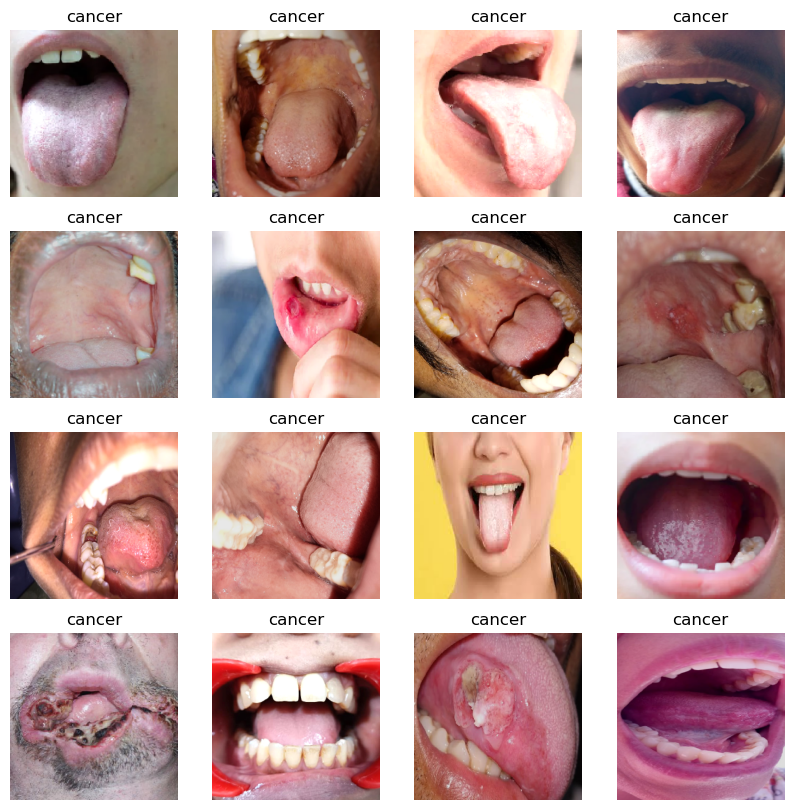

In [15]:
class_names = {v: k for k, v in class_dict.items()}
# print(class_names)
images, labels = next(validation_data)
# print(images.shape)

plt.figure(figsize = (10, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.axis('off')
    label_index = np.argmax(labels[i])
    class_name = class_names[label_index]
    plt.title(class_name)
    plt.imshow(images[i])
plt.show()

## Create a network

In [16]:
model = Sequential([
    Input(shape = (img_size, img_size, 3)),
    Conv2D(32, kernel_size = (3, 3), strides = 1, padding = 'same', activation = 'relu'),
    MaxPooling2D(pool_size = (2, 2), strides = 2, padding = 'valid'),
    Dropout(0.2),
    
    Conv2D(64, kernel_size = (3, 3), strides = 1, padding = 'same', activation = 'relu'),
    MaxPooling2D(pool_size = (2, 2), strides = 2, padding = 'valid'),
    Dropout(0.2),
    
    Conv2D(128, kernel_size = (3, 3), strides = 1, padding = 'same', activation = 'relu'),
    MaxPooling2D(pool_size = (2, 2), strides = 2, padding = 'valid'),
    
    Flatten(),
    Dense(128, activation = 'relu'),
    Dropout(0.5),

    Dense(1, activation = 'sigmoid')
])


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 300, 300, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 175232)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    22,429,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,523,201 (85.92 MB)

 Trainable params: 22,523,201 (85.92 MB)

 Non-trainable params: 0 (0.00 B)

## Compile the model

In [18]:
model.compile(optimizer = Adam(learning_rate = 0.001), loss = 'binary_crossentropy', metrics = ['accuracy'])

## Train the model

In [19]:
history = model.fit(train_data,
                    epochs = 10,
                    validation_data = validation_data,
                    batch_size = batch_size
                   )

c:\Users\venun\anaconda3\New folder\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


c:\Users\venun\anaconda3\New folder\Lib\site-packages\PIL\Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


43/43 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.5562 - loss: 1.7928 - val_accuracy: 0.5888 - val_loss: 0.6878
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.6139 - loss: 0.6729 - val_accuracy: 0.7426 - val_loss: 0.6307
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.7034 - loss: 0.5946 - val_accuracy: 0.7574 - val_loss: 0.5232
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.7655 - loss: 0.5228 - val_accuracy: 0.7811 - val_loss: 0.5079
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - accuracy: 0.7951 - loss: 0.4613 - val_accuracy: 0.7899 - val_loss: 0.4654
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.8306 - loss: 0.4024 - val_accuracy: 0.7781 - val_loss: 0.4609
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.8491 - loss: 0.3541 - val_accuracy: 0.8077 - val_loss: 0.4594
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.8558 - loss: 0.3346 - val_accuracy: 0.8284 - val_loss: 0.4705

## Save the model

In [20]:
model.save('oral-cancer-model.keras')

## Plot the performance

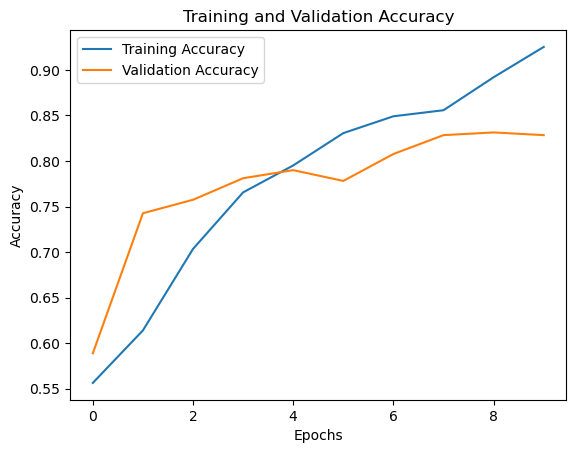

In [21]:
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

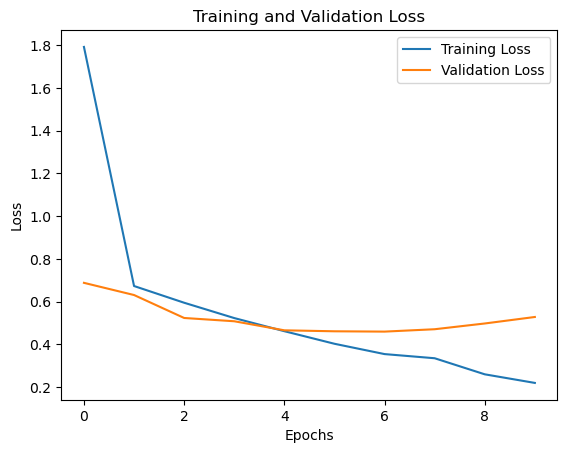

In [22]:
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Evaluate the model

In [23]:
loss, accuracy = model.evaluate(validation_data)

print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 422ms/step - accuracy: 0.8314 - loss: 0.5278
Test Loss: 0.527778148651123
Test Accuracy: 0.831360936164856
